In [7]:
import pandas as pd
import glob
import json
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
from  scipy import optimize

<Axes: title={'center': 'Polarization Over Time'}, xlabel='Datetime', ylabel='Polarization'>

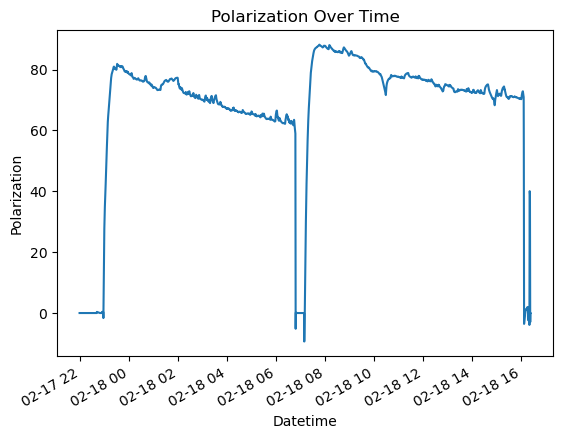

In [2]:
with open("event_json/2009-02-18_16h23m46s.json","r") as eventfile:
    df = pd.read_json(eventfile, lines=True)
df['stop_time'] = pd.to_datetime(df['stop_time'])
df.set_index('stop_time', inplace=True)

# Plot the polarization over time
df['pol'].plot(title='Polarization Over Time',
                      xlabel='Datetime',
                      ylabel='Polarization')

In [20]:
i = 100

cent = float(df.iloc[i]['cent_freq'])
mod  = float(df.iloc[i]['mod_freq'])

phase = np.array(df.iloc[i]['phase'], dtype=float)
freq_list = np.linspace((cent - mod)/1e6, (cent + mod)/1e6, 500)

In [18]:
df.head()

,area,cc,pol,cent_freq,mod_freq,gain,sweeps,steps,qmeter_num,bath_temp,uwave_freq,phase
stop_time,,,,,,,,,,,,
2009-02-17 21:58:38,0.0,0.0,0.0,0,0,0.0,0,0,0,1.259,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2009-02-17 21:59:08,0.0,0.0,0.0,0,0,0.0,0,0,0,1.259,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2009-02-17 21:59:38,0.0,0.0,0.0,0,0,0.0,0,0,0,1.259,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2009-02-17 22:07:08,0.0,0.0,0.0,0,0,0.0,0,0,0,-1.000,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2009-02-17 22:08:03,0.0,0.0,0.0,0,0,0.0,0,0,0,1.288,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [19]:
print(cent)

213000000.0


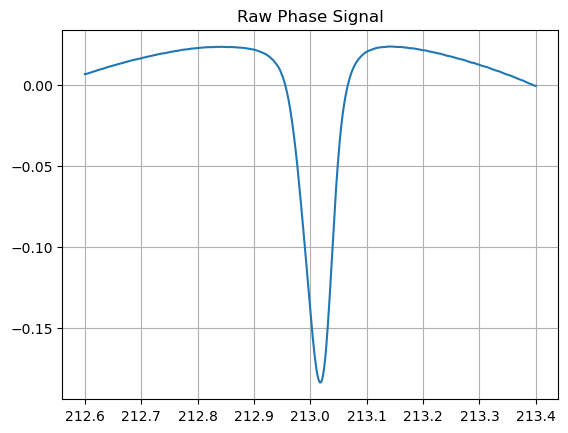

In [21]:
plt.plot(freq_list, phase)
plt.title('Raw Phase Signal')
plt.grid()
plt.show()

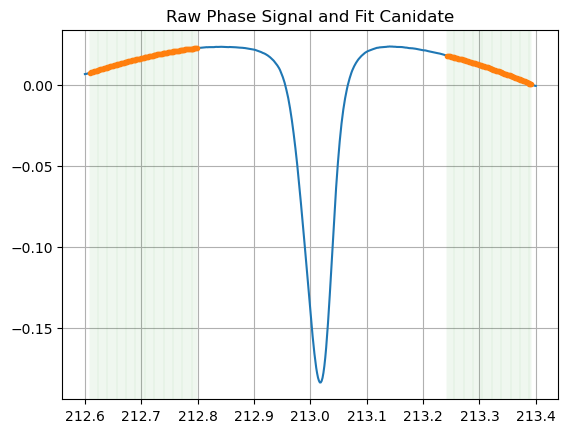

In [39]:
# Create bounds for the wings w/ fractions of the array length
wings = [0.01, 0.25, 0.8, 0.99]
bounds = [x * len(phase) for x in wings]

# Select (freq, phase) points from the left and right wings of the signal
data = [z for x, z in enumerate(zip(freq_list, phase)) if (bounds[0] < x < bounds[1] or bounds[2] < x < bounds[3])]

X = np.array([x for x, y in data])
Y = np.array([y for x, y in data])

plt.plot(freq_list, phase)
for x in X:
    plt.axvline(x, color='green', alpha=0.03)
plt.plot(X, Y, '.')
plt.title("Raw Phase Signal and Fit Canidate")
plt.grid()
plt.show()

c:\Users\evant\anaconda3\Lib\site-packages\scipy\optimize\_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


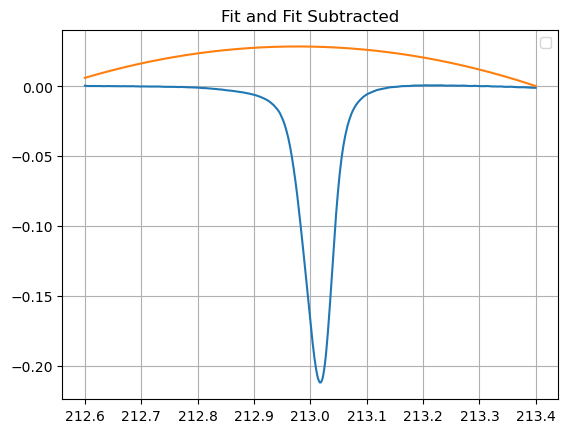

In [68]:
def poly3(x, *p):  # default poly is 3rd order
    return p[0] + p[1] * x + p[2] * np.power(x, 2) + p[3] * np.power(x, 3)

pi = [0.01, 0.8, 0.01, 0.001, 0.00001, 0.00001, 0.00001, 0.00001, 0.00001]
pf, pcov = optimize.curve_fit(poly3, X, Y, p0=pi)
pstd = np.sqrt(np.diag(pcov))

fit = poly3(freq_list, *pf)
sub = phase - fit

plt.plot(freq_list, sub)
plt.plot(freq_list, fit)
plt.title("Fit and Fit Subtracted")
plt.grid()
plt.legend()
plt.show()

In [ ]:
cali_constant = float(df.iloc[i]['cc'])
area = sub.sum()
pol = area * cali_constant

print("Summed final signal:",area)
print("Polarization:", pol)
print(f"df['pol']: {df.iloc[i]['pol']}")

Summed final signal: -9.114774708361521
Polarization: 21.828062471584172
df['pol']: 22.22


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


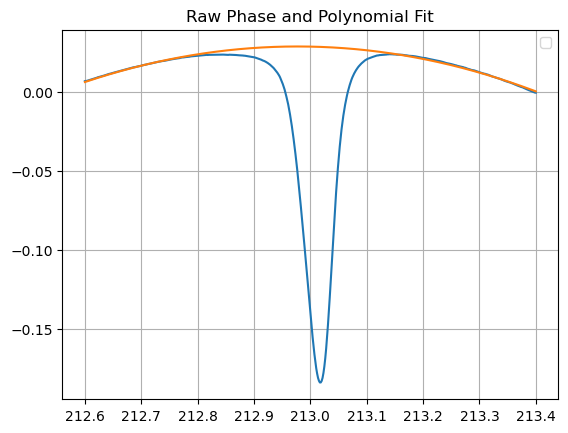

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


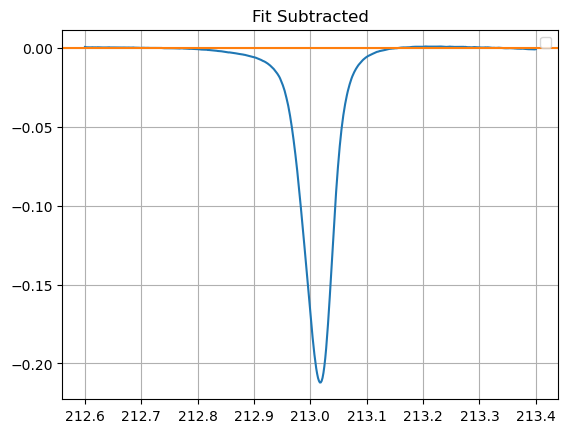

In [69]:
plt.plot(freq_list, phase)
plt.plot(freq_list, fit)
plt.title("Raw Phase and Polynomial Fit")
plt.grid()
plt.legend()
plt.show()

plt.plot(freq_list, sub)
plt.axhline(0, linewidth=1.5, color='tab:orange')
plt.title("Fit Subtracted")
plt.grid()
plt.legend()
plt.show()